In [1]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *
from simulations.src import *

In [2]:
manifold_type = 'S1'; manifold = get_manifold(manifold_type)

# n_samples_ls = [100, 500, 1000, 2500, 5000, 7500, 10000,25000, 50000]
n_samples_ls =  [100, 500, 1000, 2500, 5000, 7500, 10000]

manifold_type = 'S1'

G_sampler_ls = [
    get_G_class(manifold_type, sampler, name, params) for sampler, name, params 
        in [
            (multimodal_sampler, '1-modal', {'tau2' : 0.05, 'num_modes' : 1}),
            (multimodal_sampler, '2-modal', {'tau2' : 0.05, 'num_modes' : 2}),
            (multimodal_sampler, '3-modal', {'tau2' : 0.05, 'num_modes' : 3}),
            (multimodal_sampler, '4-modal', {'tau2' : 0.01, 'num_modes' : 4}),
        ]
    ]
sigma2 = 0.1

NMC = 25

test_size = 1000
num_oracle_samples = 10000

M_grid= np.arange(1, 9)
rho_grid = [0.015, 0.025, 0.045, 0.065, 0.085, 0.10, 0.125, 0.15, 0.175, 0.2]


In [3]:
results_mc = []
results_ocv = []
for G in G_sampler_ls:
    dfmc, dforaclecv = converenge_rate_experiment(manifold_type, G, n_samples_ls, M_grid, rho_grid, sigma2, test_size, num_oracle_samples, NMC, cv=True)
    results_mc.append(dfmc)
    results_ocv.append(dforaclecv)
results_mc = pd.concat(results_mc, ignore_index=True)
results_ocv = pd.concat(results_ocv, ignore_index=True)

G="1-modal", σ²=0.1:   0%|          | 0/14000 [00:00<?, ?it/s]

G="2-modal", σ²=0.1:   0%|          | 0/14000 [00:00<?, ?it/s]

G="3-modal", σ²=0.1:   0%|          | 0/14000 [00:00<?, ?it/s]

G="4-modal", σ²=0.1:   0%|          | 0/14000 [00:00<?, ?it/s]

In [4]:
for name, results in zip(['mc', 'ocv'], [results_mc, results_ocv]):

    filepath = 'data/{}/rate_{}_{}.csv'.format(manifold_type,manifold_type,name)

    if os.path.exists(filepath):
        print(f"'{filepath}' already exists.")
        choice = input("Choose an option — [c] concatenate, [o] overwrite, [n] do nothing: ").strip().lower()
        
        if choice == 'c':
            existing = pd.read_csv(filepath)
            combined = pd.concat([existing, results], ignore_index=True).drop_duplicates()
            combined.to_csv(filepath, index=False)
            print(f"Files concatenated and saved ({len(combined)} rows, duplicates removed).")
        elif choice == 'o':
            results.to_csv(filepath, index=False)
            print("File overwritten.")
        elif choice == 'n':
            print("No changes made.")
        else:
            print("Invalid input. No changes made.")
    else:
        results.to_csv(filepath, index=False)
        print(f"File saved to '{filepath}'.")


'data/S1/rate_S1_mc.csv' already exists.
File overwritten.
'data/S1/rate_S1_ocv.csv' already exists.
File overwritten.


-----

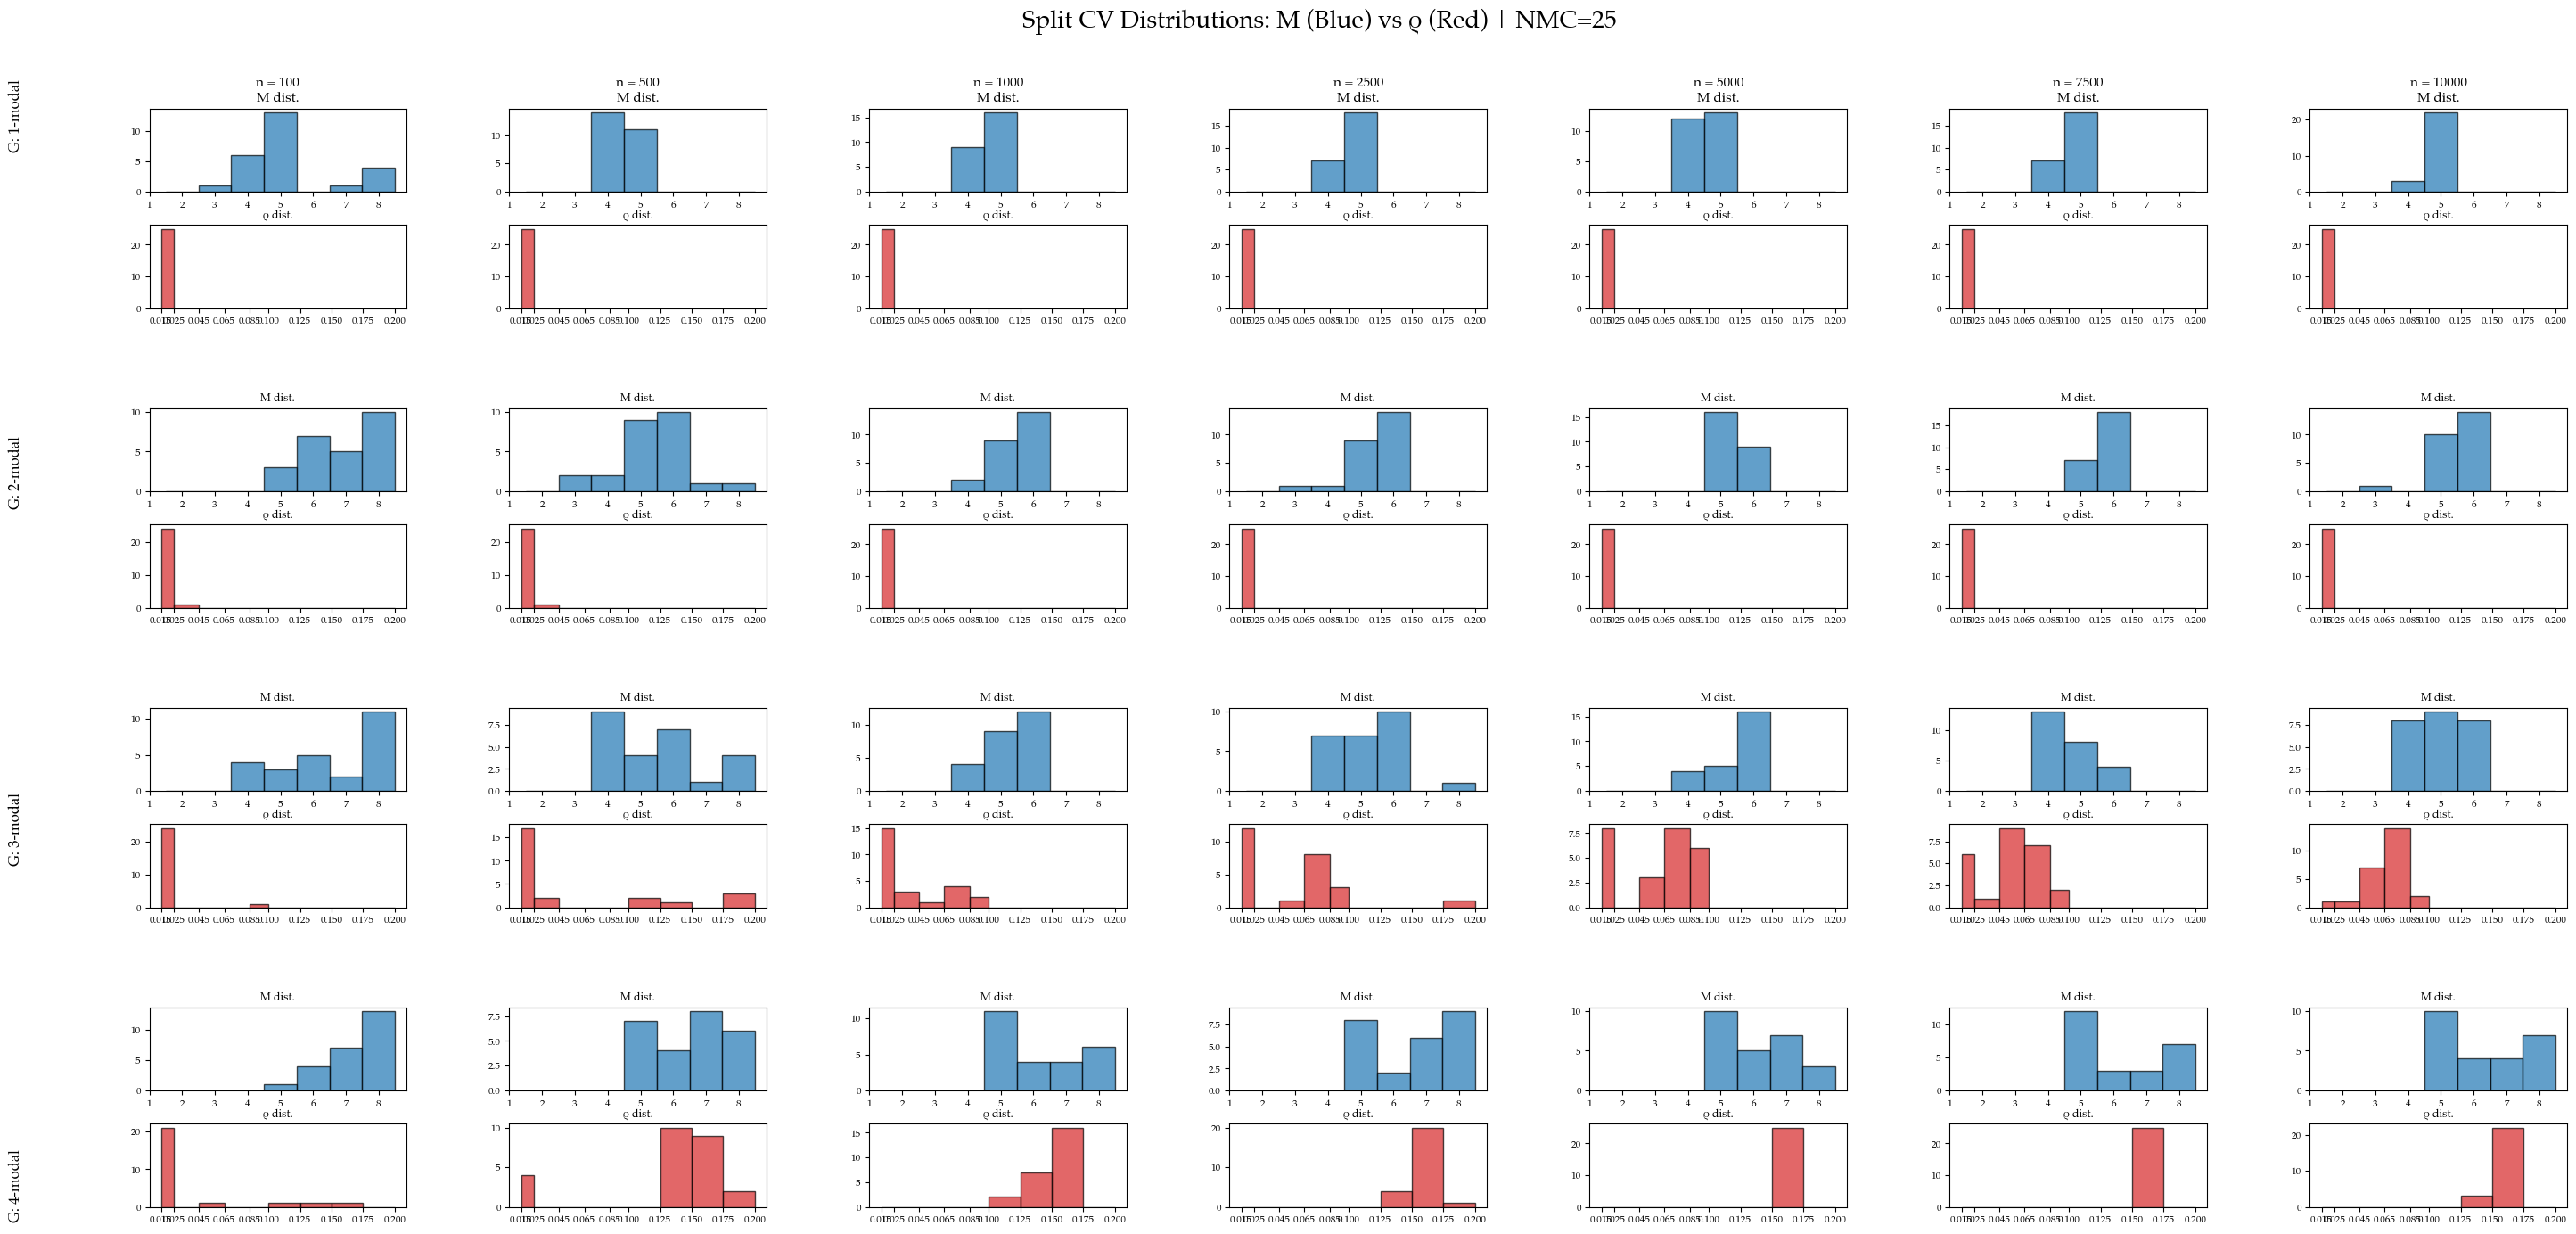

In [5]:

# Execution
plot_cv_distributions_split(results_ocv, NMC)

In [6]:
# Snap the theoretical choices to the nearest available grid values (and keep them in-range)
extselected_Mrho = {}

M_grid_arr = np.asarray(M_grid, dtype=float)
rho_grid_arr = np.asarray(rho_grid, dtype=float)

for G in G_sampler_ls:
    n_arr = np.asarray(n_samples_ls, dtype=float)

    # original (continuous) rules
    rho_raw =  .5*(n_arr ** (-1/5))
    # print(rho_raw)
    M_raw = np.log(n_arr) - 1

    # nearest grid points
    rho_snap = rho_grid_arr[np.argmin(np.abs(rho_raw[:, None] - rho_grid_arr[None, :]), axis=1)]
    M_snap = M_grid_arr[np.argmin(np.abs(M_raw[:, None] - M_grid_arr[None, :]), axis=1)].astype(int)

    extselected_Mrho[G.name] = {"rho": rho_snap, "M": M_snap}

In [19]:
plot_mcratesims_interactive(manifold_type, results_mc, results_ocv, G_sampler_ls, NMC, extselected_Mrho )

Output()

-----

-----

-----

-----

-----

-----

-----

-----

-----

In [3]:
cv_selected_Mrho = []
M_grid = np.arange(2, 9)
rho_grid = [0.025, 0.05, 0.075, 0.1, 0.125, 0.125, 0.175, 0.2]

total = len(G_sampler_ls) * len(n_samples_ls)
with tqdm(total=total, desc="Density CV over (G, n)", unit="task") as pbar:
    for G in G_sampler_ls:
        for n in n_samples_ls:
            Theta = G.sample(n)
            X = manifold.random_riemannian_normal(Theta, 1 / sigma2, n)

            Mrhostar , cv_scores =  select_M_rho_by_scoreMatchingKFoldCV(manifold_type, X, M_grid, rho_grid, n_splits=10, return_scores=True, random_state=42)


            cv_selected_Mrho.append({
                "G": G.name,
                "sigma2": sigma2,
                "n": n,
                "M": Mrhostar["cv"][0],
                "rho": Mrhostar["cv"][1],
            })

            pbar.set_postfix(G=G.name, n=n, M=Mrhostar["cv"][0], rho=Mrhostar["cv"][1])
            pbar.update(1)

cv_selected_Mrho_df = pd.DataFrame(cv_selected_Mrho)
display(cv_selected_Mrho_df)
# cv_selected_Mrho_df.to_csv('data/{}/cv_selected_Mrho.csv'.format(manifold_type), index=False)

Density CV over (G, n): 100%|██████████| 36/36 [00:14<00:00,  2.41task/s, G=4-modal, M=5, n=5e+4, rho=0.125] 


,G,sigma2,n,M,rho
0,1-modal,0.1,100,4,0.025
1,1-modal,0.1,500,4,0.025
2,1-modal,0.1,1000,3,0.025
3,1-modal,0.1,2500,3,0.025
4,1-modal,0.1,5000,4,0.025
5,1-modal,0.1,7500,4,0.025
6,1-modal,0.1,10000,4,0.025
7,1-modal,0.1,25000,4,0.025
8,1-modal,0.1,50000,4,0.025
9,2-modal,0.1,100,7,0.025


------

In [4]:
results = pd.read_csv(filepath)

In [5]:
plot_mcratesims_interactive(manifold_type, results[results.num_samples > 1], G_sampler_ls, NMC)

Output()

-----

-----

-----

-----

-----

-----

-----

In [116]:
selected_G = G_sampler_ls[0]
selected_M = M_grid[5]
selected_rho = rho_grid[9]
print(selected_rho)
# plot_mcratesims(manifold_type, results, G_sampler_ls, selected_M, selected_rho, NMC, savefig=None)


1e-06


Density CV over (G, n):   0%|          | 0/28 [00:00<?, ?task/s]